# 01 — Weekly features

Build weekly series from daily inputs and merge into `market_features_weekly.csv`.

In [5]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent))
from regime_utils import *

# Weekly resample: W-FRI, last observation in each week
for daily_name, weekly_name, price_col in [
    ("sp500.csv", "sp500_weekly.csv", "Adj Close"),
    ("vix.csv", "vix_weekly.csv", "Adj Close"),
    ("t10y2y.csv", "t10_weekly.csv", "T10Y2Y"),
]:
    s = read_csv(daily_name, parse_dates=["Date"]).set_index("Date").sort_index()
    weekly = s.resample("W-FRI").last().dropna(how="all")
    write_csv(weekly.reset_index(), weekly_name)
    print(f"Wrote {weekly_name}: {len(weekly)} rows")

sp500 = read_csv("sp500_weekly.csv", parse_dates=["Date"]).set_index("Date")
vix = read_csv("vix_weekly.csv", parse_dates=["Date"]).set_index("Date")
yields = read_csv("t10_weekly.csv", parse_dates=["Date"]).set_index("Date")

sp500_features = sp500[["Adj Close"]].rename(columns={"Adj Close": "SP500"})
sp500_features["SP500_Return"] = np.log(sp500_features["SP500"]).diff()
vix_features = vix[["Adj Close"]].rename(columns={"Adj Close": "VIX"})
yield_features = yields[["T10Y2Y"]].rename(columns={"T10Y2Y": "Yield_Spread"})

features = sp500_features.join(vix_features, how="inner").join(yield_features, how="inner")
features = features.dropna()
print(features.head())
print(features.isna().sum())
write_csv(features.reset_index(), "market_features_weekly.csv")


Wrote sp500_weekly.csv: 1565 rows
Wrote vix_weekly.csv: 1565 rows
Wrote t10_weekly.csv: 1565 rows
                 SP500  SP500_Return    VIX  Yield_Spread
Date                                                     
1994-01-14  474.910004      0.010605  11.15          1.61
1994-01-21  474.720001     -0.000400  11.09          1.64
1994-01-28  478.700012      0.008349   9.94          1.60
1994-02-04  469.809998     -0.018746  15.25          1.52
1994-02-11  470.179993      0.000787  14.46          1.44
SP500           0
SP500_Return    0
VIX             0
Yield_Spread    0
dtype: int64


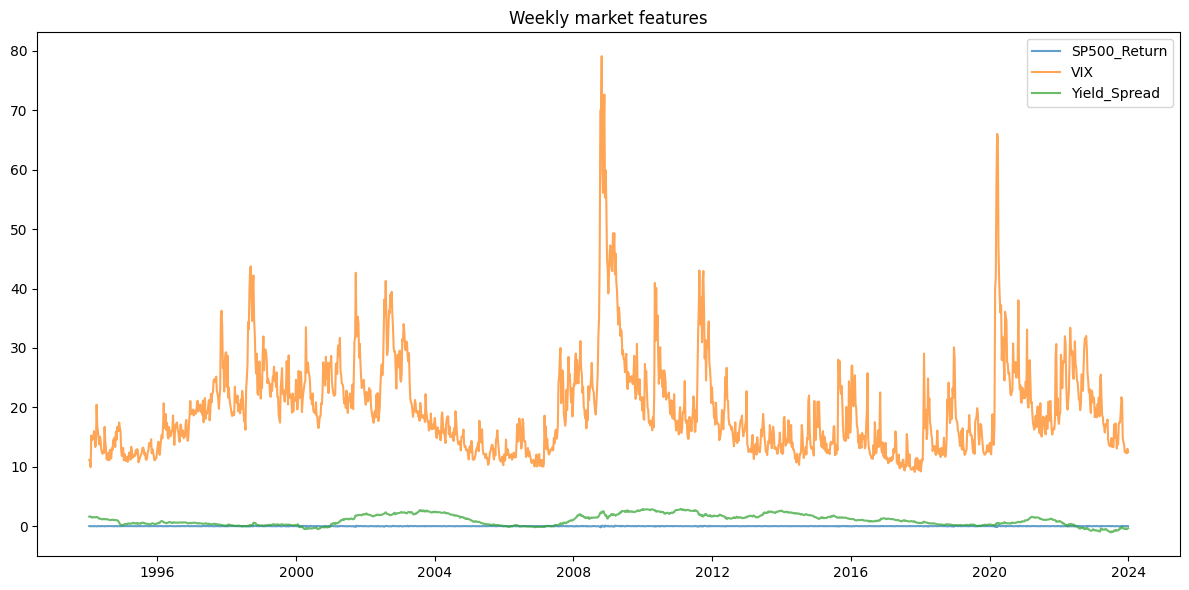

In [6]:

plt.figure(figsize=(12, 6))
for col in MODEL_FEATURES:
    plt.plot(features.index, features[col], label=col, alpha=0.7)
plt.legend(); plt.title("Weekly market features"); plt.tight_layout(); plt.show()
